# 05 - Signal Validation

Evaluates whether Polymarket probability shifts are reliable predictors of freight rate changes.  
This is not a trading or PnL simulation — it assesses **signal quality** so supply chain teams can decide how much weight to place on each prediction market signal.

## Metrics computed per market-freight pairing

| Metric | Question answered |
|---|---|
| **Precision** | Of all signals that fired, what % were followed by freight moving in the expected direction? |
| **Recall** | Of all significant freight moves, what % were preceded by a Polymarket signal? |
| **F1** | Harmonic mean of precision and recall. |
| **Lead time** | How many days before the freight move did the signal fire? |

**Classification logic:**
- **TP** — signal fired → freight moved in the expected direction within the outcome window
- **FP** — signal fired → no matching freight move within the outcome window
- **FN** — freight moved → no preceding signal within the lookback window

The expected direction for freight is derived from the cross-correlation sign: if `peak_correlation > 0`, a rising probability implies rising freight; if `< 0`, a rising probability implies falling freight.

In [48]:
import sys
import pickle
from pathlib import Path

# Locate project root regardless of where Jupyter was launched.
# CLAUDE.md lives at the project root — use it as an unambiguous marker.
_cwd = Path.cwd()
if (_cwd / 'CLAUDE.md').exists():
    BASE = _cwd            # launched from project root (e.g. VS Code Jupyter)
elif (_cwd.parent / 'CLAUDE.md').exists():
    BASE = _cwd.parent     # launched from notebooks/ directory
else:
    BASE = _cwd            # fallback

sys.path.insert(0, str(BASE))

import logging
logging.basicConfig(level=logging.INFO)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'

print(f'Project base: {BASE.resolve()}')

Project base: C:\Users\kekoi\Projects\operations_research\polymarket-scm-intel


## Step 1: Load data

Loads from the analysis cache produced in NB 03.  
If the cache is missing, recomputes on-the-fly (slower).

In [49]:
import yaml
from src.polymarket.market_discovery import load_discovered_markets
from src.freight.scraper import fetch_all_freight_indexes
from src.freight.normalize import prepare_freight_panel
from src.analysis.events import EventDetector
from src.analysis.correlation import CorrelationAnalyser, compute_cross_correlation

# Panel CSV may be written relative to the notebooks/ dir or the project root
# depending on which directory Jupyter was in when NB 02 was run.
_panel_candidates = [
    BASE / 'data/processed/timeseries_panel.csv',
    BASE / 'notebooks/data/processed/timeseries_panel.csv',
]
PANEL_PATH = next((p for p in _panel_candidates if p.exists()), _panel_candidates[0])

# Analysis cache is always written to the project root data/processed/
_cache_candidates = [
    BASE / 'data/processed/analysis_cache.pkl',
    BASE / 'notebooks/data/processed/analysis_cache.pkl',
]
ANALYSIS_CACHE = next((p for p in _cache_candidates if p.exists()), _cache_candidates[0])

print(f'Panel CSV     : {PANEL_PATH}  (exists={PANEL_PATH.exists()})')
print(f'Analysis cache: {ANALYSIS_CACHE}  (exists={ANALYSIS_CACHE.exists()})')

# ── Markets ───────────────────────────────────────────────────────────────────
markets_df = load_discovered_markets()
sc_markets = markets_df[markets_df['category'].notna()].copy()
print(f'\nMarkets total: {len(markets_df):,}  |  SC-relevant: {len(sc_markets):,}')

# ── Timeseries ────────────────────────────────────────────────────────────────
if PANEL_PATH.exists():
    panel = pd.read_csv(PANEL_PATH, parse_dates=['date'])
    timeseries = {str(mid): grp.reset_index(drop=True) for mid, grp in panel.groupby('market_id')}
    print(f'Timeseries: {len(timeseries):,} markets from cache')
else:
    print('WARNING: timeseries_panel.csv not found — timeseries will be empty.')
    print('  Validation will still work if analysis_cache.pkl has all_events and xcorr_results.')
    timeseries = {}

# ── Freight data ──────────────────────────────────────────────────────────────
freight_raw  = fetch_all_freight_indexes(use_synthetic_fallback=True)
freight_data = prepare_freight_panel(freight_raw)
print(f'Freight indexes: {list(freight_data.keys())}')

# ── Analysis results ──────────────────────────────────────────────────────────
detector = EventDetector()
analyser  = CorrelationAnalyser()

if ANALYSIS_CACHE.exists():
    with open(ANALYSIS_CACHE, 'rb') as f:
        _cache = pickle.load(f)
    all_events    = _cache['all_events']
    xcorr_results = _cache['xcorr_results']
    print(f'Cache: {len(all_events):,} events, {len(xcorr_results):,} xcorr pairs')
else:
    print('Cache not found — recomputing (run NB 03 first to speed this up).')
    all_events    = detector.detect_all(timeseries, markets_df)
    xcorr_results = analyser.run_cross_correlations(timeseries, freight_data, markets_df)

# ── Fallback: compute xcorr for SC markets if cache was empty ─────────────────
if not xcorr_results and timeseries:
    print('xcorr_results empty — computing on-the-fly for SC markets...')
    id_to_title = {str(r['market_id']): str(r['title']) for _, r in sc_markets.iterrows()}
    xcorr_results = []
    for mid_str, title in id_to_title.items():
        poly_df = timeseries.get(mid_str)
        if poly_df is None:
            continue
        for fi_name, fdf in freight_data.items():
            result = compute_cross_correlation(mid_str, title, poly_df, fdf, fi_name)
            if result is not None:
                xcorr_results.append(result)
    print(f'  computed {len(xcorr_results)} xcorr pairs for SC markets')

events_df = detector.to_dataframe(all_events)
xcorr_df  = analyser.xcorr_to_dataframe(xcorr_results)
print(f'\nReady. Events: {len(all_events):,} | XCorr pairs: {len(xcorr_results):,}')

Panel CSV     : c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\data\processed\timeseries_panel.csv  (exists=True)
Analysis cache: c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\data\processed\analysis_cache.pkl  (exists=True)

Markets total: 35,912  |  SC-relevant: 7,151


INFO:src.freight.scraper:Fetching freight index: BDI
INFO:src.freight.scraper:Loaded 522 rows from data\freight\bdi.csv
INFO:src.freight.scraper:  → 522 observations for BDI
INFO:src.freight.scraper:Fetching freight index: FBX_GLOBAL
INFO:src.freight.scraper:Loaded 27 WCI rows for FBX_GLOBAL from data\freight\fbx_global.csv
INFO:src.freight.scraper:  → 27 observations for FBX_GLOBAL
INFO:src.freight.scraper:Fetching freight index: FBX01
INFO:src.freight.scraper:Extracted FBX01 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX01
INFO:src.freight.scraper:Fetching freight index: FBX03
INFO:src.freight.scraper:Extracted FBX03 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX03
INFO:src.freight.scraper:Fetching freight index: FBX11
INFO:src.freight.scraper:Extracted FBX11 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX11


Timeseries: 5,790 markets from cache


INFO:src.freight.normalize:Normalising freight index: BDI
INFO:src.freight.normalize:  BDI: 761 daily observations from 2024-01-22 to 2026-02-20
INFO:src.freight.normalize:Normalising freight index: FBX_GLOBAL
INFO:src.freight.normalize:  FBX_GLOBAL: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX01
INFO:src.freight.normalize:  FBX01: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX03
INFO:src.freight.normalize:  FBX03: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX11
INFO:src.freight.normalize:  FBX11: 372 daily observations from 2025-02-13 to 2026-02-19


Freight indexes: ['BDI', 'FBX_GLOBAL', 'FBX01', 'FBX03', 'FBX11']
Cache: 4,075 events, 1,102 xcorr pairs

Ready. Events: 4,075 | XCorr pairs: 1,102


## Step 2: Filter to SC-relevant pairings

Apply a **positive title filter** using supply-chain-specific keywords before running validation.
This removes spurious matches (sports leagues, entertainment, domestic politics) that entered the
xcorr dataset because broad category keywords like "China" or "war" matched unrelated markets.

Only markets whose titles contain at least one unambiguous SC signal keyword are kept.

In [50]:
import re

# Positive filter: title must contain at least one of these SC-specific patterns.
# Deliberately avoids broad terms like "China" or "war" alone that catch sports/politics.
SC_PATTERNS = [
    # Trade & tariffs
    r'\btariff[s]?\b', r'\bIEEPA\b', r'\btrade war\b', r'\btrade deal\b',
    r'\btrade agreement\b', r'\bimport (tax|duty)\b', r'\bexport ban\b',
    r'\breciprocal tariff\b', r'\bSection 301\b', r'\bSection 232\b',
    r'\bembargo\b', r'\bWTO\b', r'\bUSMCA\b', r'\bcustoms duty\b',
    # Sanctions (trade-related context)
    r'\bsanction[s]?\b',
    # Shipping & ports
    r'\bshipping\b', r'\bfreight\b', r'\bport strike\b', r'\bILA\b',
    r'\blongshoremen\b', r'\bdockworkers?\b', r'\bcontainer rate\b',
    r'\bsupply chain\b',
    # Geopolitical with direct SC impact
    r'\bHouthi\b', r'\bRed Sea\b', r'\bSuez\b', r'\bYemen.*attack\b',
    r'\bHormuz\b', r'\bIran.*(strike|attack|sanction|nuclear|military)\b',
    r'\b(strike|attack|sanction|military).*Iran\b',
    # Taiwan Strait (major semiconductor + shipping risk)
    r'\bTaiwan (strait|invasion|blockade|military|conflict)\b',
    r'\bSouth China Sea\b',
]

def is_sc_relevant(title: str) -> bool:
    """Return True if the market title contains at least one SC-specific keyword."""
    for pat in SC_PATTERNS:
        if re.search(pat, title, flags=re.IGNORECASE):
            return True
    return False

# Filter xcorr_results to SC-relevant markets only
sc_market_ids = set(sc_markets['market_id'].astype(str))

xcorr_sc = [
    r for r in xcorr_results
    if str(r.market_id) in sc_market_ids and is_sc_relevant(r.market_title)
]
xcorr_sc_df = analyser.xcorr_to_dataframe(xcorr_sc)

n_before = len([r for r in xcorr_results if str(r.market_id) in sc_market_ids])
print(f'SC-category pairings before title filter : {n_before}')
print(f'SC-relevant pairings after title filter  : {len(xcorr_sc)}')
print(f'  Polymarket leads (lag > 0)             : {(xcorr_sc_df["peak_lag_days"] > 0).sum()}')
print(f'  Statistically significant (p < 0.05)   : {xcorr_sc_df["is_significant"].sum()}')

if not xcorr_sc_df.empty:
    display_cols = ['market_title', 'freight_index', 'peak_lag_days',
                    'peak_correlation', 'peak_p_value', 'polymarket_leads', 'is_significant']
    display(xcorr_sc_df[display_cols]
            .sort_values('peak_correlation', key=abs, ascending=False)
            .head(15))
else:
    print('No SC xcorr results — check SC_PATTERNS or market_mappings.yaml.')
    xcorr_sc = xcorr_results  # fallback: validate all

SC-category pairings before title filter : 1102
SC-relevant pairings after title filter  : 489
  Polymarket leads (lag > 0)             : 259
  Statistically significant (p < 0.05)   : 461


,market_title,freight_index,peak_lag_days,peak_correlation,peak_p_value,polymarket_leads,is_significant
2,Houthi strike on Israel by August 31?,FBX11,-24,0.970118,3.364912e-06,False,True
3,Houthi strike on Israel by August 31?,FBX_GLOBAL,-24,0.970118,3.364912e-06,False,True
276,Will Trump impose tariffs on Taiwan before March?,FBX03,-18,0.958430,2.487204e-07,False,True
313,Will Trump agree to a tariff agreement with Ge...,FBX01,19,-0.950109,7.537126e-06,True,True
7,Supreme Court rules in favor of Trump's tariffs?,FBX01,0,0.940321,1.233352e-14,False,True
418,Will Trump agree to a tariff agreement with Is...,FBX03,-19,-0.932276,2.904784e-05,False,True
417,Will Trump agree to a tariff agreement with Is...,FBX01,-19,-0.932276,2.904784e-05,False,True
443,Will Trump agree to a tariff agreement with Is...,FBX01,-20,-0.930898,3.173882e-05,False,True
444,Will Trump agree to a tariff agreement with Is...,FBX03,-20,0.930898,3.173882e-05,False,True
446,Will Trump agree to a tariff agreement with Au...,FBX03,20,0.930475,3.260114e-05,True,True


## Step 3: Detect freight events

Significant freight rate moves are detected using a rolling threshold (default: ≥8% change over 14 days).  
These are the "outcomes" that signals are expected to predict.

In [51]:
from src.analysis.validation import detect_freight_events

FREIGHT_THRESHOLD_PCT = 0.08   # 8% move counts as a significant freight event
FREIGHT_EVENT_WINDOW  = 14     # rolling window in days

freight_events_by_index = {}
for fi_name, freight_df in freight_data.items():
    events = detect_freight_events(
        freight_df, fi_name,
        threshold_pct=FREIGHT_THRESHOLD_PCT,
        window=FREIGHT_EVENT_WINDOW,
    )
    freight_events_by_index[fi_name] = events
    print(f'  {fi_name}: {len(events)} significant freight events detected')

# Show freight events table
all_freight_events = [
    {'freight_index': fi, 'timestamp': e.timestamp,
     'pct_change': round(e.pct_change, 2), 'direction': e.direction,
     'value_before': round(e.value_before, 1), 'value_after': round(e.value_after, 1)}
    for fi, evs in freight_events_by_index.items() for e in evs
]
freight_events_df = pd.DataFrame(all_freight_events).sort_values('timestamp')
print(f'\nTotal freight events across all indexes: {len(freight_events_df)}')
display(freight_events_df)

  BDI: 27 significant freight events detected
  FBX_GLOBAL: 16 significant freight events detected
  FBX01: 16 significant freight events detected
  FBX03: 18 significant freight events detected
  FBX11: 14 significant freight events detected

Total freight events across all indexes: 91


,freight_index,timestamp,pct_change,direction,value_before,value_after
0,BDI,2024-03-04,41.01,up,1629.0,2297.0
1,BDI,2024-04-02,-28.34,down,2392.0,1714.0
2,BDI,2024-04-22,18.07,up,1594.0,1882.0
3,BDI,2024-05-09,24.27,up,1743.0,2166.0
4,BDI,2024-05-23,-17.08,down,2166.0,1796.0
...,...,...,...,...,...,...
26,BDI,2026-01-30,37.08,up,1567.0,2148.0
41,FBX_GLOBAL,2026-02-05,-8.26,down,3025.0,2775.0
58,FBX01,2026-02-19,-12.00,down,2500.0,2200.0
42,FBX_GLOBAL,2026-02-19,-9.91,down,2775.0,2500.0


## Step 4: Run validation

For each SC-relevant market-freight pairing, classify every signal event as TP, FP, or FN  
using a 30-day outcome window and a 30-day lookback window.

In [52]:
from src.analysis.validation import SignalValidator

validator = SignalValidator(
    outcome_window=30,           # days after signal to look for a matching freight move
    lookback_window=30,          # days before freight event to look for a preceding signal
    freight_threshold_pct=FREIGHT_THRESHOLD_PCT,
    freight_event_window=FREIGHT_EVENT_WINDOW,
    min_correlation_magnitude=0.10,  # skip pairs with very weak correlations
)

validations = validator.validate_all(
    all_events=all_events,
    xcorr_results=xcorr_sc if xcorr_sc else xcorr_results,
    timeseries=timeseries,
    freight_data=freight_data,
    markets_df=markets_df,
    sc_only=True,
)

print(f'Pairings validated: {len(validations)}')

INFO:src.analysis.validation:Freight events detected — BDI: 27 events
INFO:src.analysis.validation:Freight events detected — FBX_GLOBAL: 16 events
INFO:src.analysis.validation:Freight events detected — FBX01: 16 events
INFO:src.analysis.validation:Freight events detected — FBX03: 18 events
INFO:src.analysis.validation:Freight events detected — FBX11: 14 events
INFO:src.analysis.validation:Validated 1198423 × BDI: precision=0.00 recall=0.00 F1=0.00 (TP=0 FP=3 FN=27, median lead=N/A days)
INFO:src.analysis.validation:Validated 532741 × BDI: precision=1.00 recall=0.04 F1=0.07 (TP=1 FP=0 FN=26, median lead=9 days)
INFO:src.analysis.validation:Validated 567030 × FBX11: precision=0.00 recall=0.00 F1=0.00 (TP=0 FP=1 FN=14, median lead=N/A days)
INFO:src.analysis.validation:Validated 567030 × FBX_GLOBAL: precision=0.00 recall=0.00 F1=0.00 (TP=0 FP=1 FN=16, median lead=N/A days)
INFO:src.analysis.validation:Validated 984441 × BDI: precision=0.00 recall=0.00 F1=0.00 (TP=0 FP=2 FN=27, median lead

Pairings validated: 489


## Step 5: Precision & Recall Summary

One row per market-freight pairing. Sorted by F1 score.

In [53]:
summary_df = validator.to_summary_dataframe(validations)

print(f'Pairings validated      : {len(summary_df)}')
print(f'Precision > 0.5         : {(summary_df["precision"] > 0.5).sum()}')
print(f'Recall > 0.5            : {(summary_df["recall"] > 0.5).sum()}')
print(f'Polymarket leads (lag>0): {summary_df["poly_leads"].sum()}')
print('(Top 10 by F1 shown — full results in output/validation_report.md)')

TOP_N_DISPLAY = 10
display_cols = [
    'market_title', 'freight_index', 'peak_correlation', 'peak_lag_days',
    'poly_leads', 'n_signals', 'n_freight_events',
    'n_tp', 'n_fp', 'n_fn', 'precision', 'recall', 'f1',
    'median_lead_time_days',
]

if not summary_df.empty:
    display(
        summary_df[display_cols]
        .head(TOP_N_DISPLAY)
        .style
        .background_gradient(subset=['precision', 'recall', 'f1'], cmap='RdYlGn', vmin=0, vmax=1)
        .format({
            'peak_correlation': '{:.3f}',
            'precision': '{:.2f}',
            'recall': '{:.2f}',
            'f1': '{:.2f}',
            'median_lead_time_days': lambda x: f'{x:.0f}' if pd.notna(x) else '—',
        })
    )
else:
    print('No validation results.')

Pairings validated      : 489
Precision > 0.5         : 205
Recall > 0.5            : 2
Polymarket leads (lag>0): 259
(Top 10 by F1 shown — full results in output/validation_report.md)


,market_title,freight_index,peak_correlation,peak_lag_days,poly_leads,n_signals,n_freight_events,n_tp,n_fp,n_fn,precision,recall,f1,median_lead_time_days
0,Will Trump lower tariffs on Canada by December 31?,FBX03,0.161,14,True,16,18,11,5,8,0.69,0.58,0.63,11
1,Will Trump lower tariffs on Canada by December 31?,FBX01,0.203,20,True,16,16,9,7,8,0.56,0.53,0.55,10
2,"U.S. agrees to a new trade deal with ""Israel"" before 2027?",FBX_GLOBAL,0.286,8,True,6,16,6,0,11,1.00,0.35,0.52,18
3,China x Taiwan military clash by December 31?,FBX03,-0.172,29,True,10,18,7,3,10,0.70,0.41,0.52,14
4,"U.S. agrees to a new trade deal with ""Israel"" before 2027?",FBX01,0.258,20,True,6,16,6,0,12,1.00,0.33,0.50,18
5,Will Trump lower tariffs on Mexico by December 31?,FBX03,-0.170,26,True,12,18,7,5,9,0.58,0.44,0.50,7
6,Will Trump remove majority of reciprocal tariffs before 90 day deadline?,FBX03,-0.292,11,True,7,18,6,1,13,0.86,0.32,0.46,10
7,US announces withdrawal from WTO in 2025?,FBX01,0.204,-9,False,7,16,5,2,10,0.71,0.33,0.46,3
8,Will Trump lower tariffs on Mexico by December 31?,FBX01,0.158,-5,False,12,16,6,6,9,0.50,0.40,0.44,14
9,"U.S. agrees to a new trade deal with ""Brazil"" before 2027?",FBX01,0.317,29,True,6,16,5,1,12,0.83,0.29,0.43,18


## Step 6: Precision & Recall Chart

INFO:src.analysis.validation:Saved: output\figures\val_precision_recall.png
INFO:src.analysis.validation:Saved: output\figures\val_precision_recall.svg


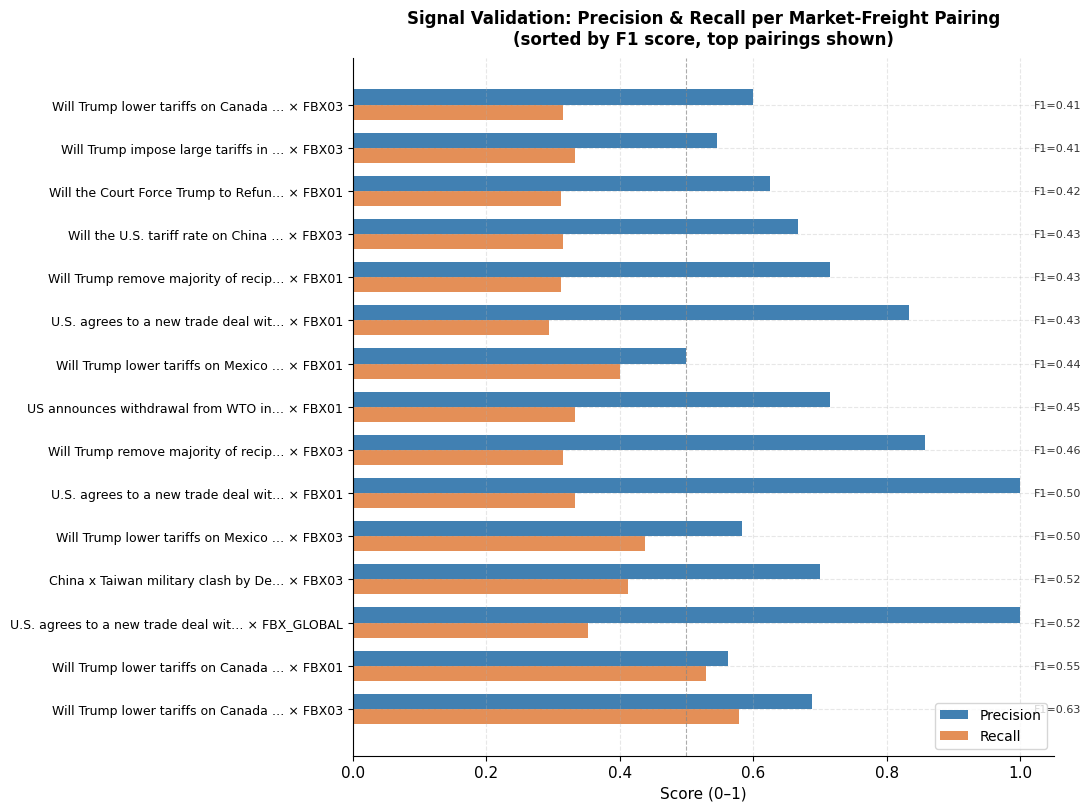

In [54]:
from src.analysis.validation import plot_precision_recall

fig = plot_precision_recall(validations, top_n=15, filename_stem='val_precision_recall')
plt.show()

## Step 7: Outcome Breakdown (TP / FP / FN)

INFO:src.analysis.validation:Saved: output\figures\val_outcome_breakdown.png
INFO:src.analysis.validation:Saved: output\figures\val_outcome_breakdown.svg


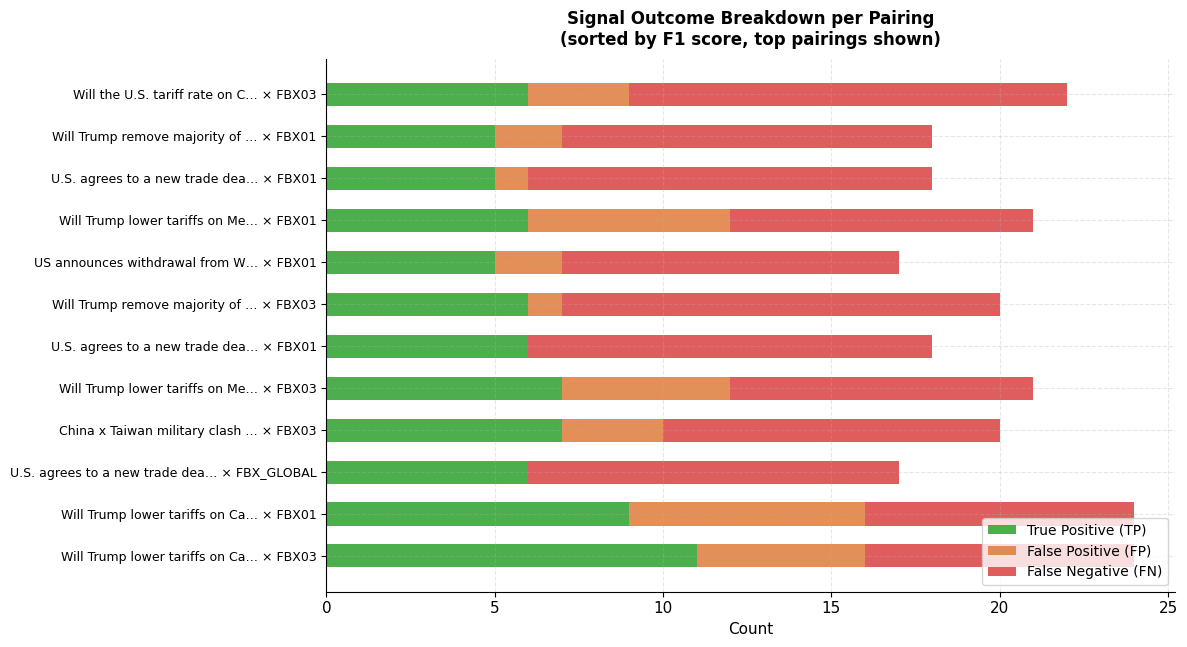

In [55]:
from src.analysis.validation import plot_outcome_breakdown

fig = plot_outcome_breakdown(validations, top_n=12, filename_stem='val_outcome_breakdown')
plt.show()

## Step 8: Lead Time Distribution

For all true-positive signals: how many days before the freight move did the signal fire?

A median lead time ≥ 5 days is generally actionable for supply chain teams (enough time to adjust routing, inventory, or procurement plans).

INFO:src.analysis.validation:Saved: output\figures\val_lead_time.png
INFO:src.analysis.validation:Saved: output\figures\val_lead_time.svg


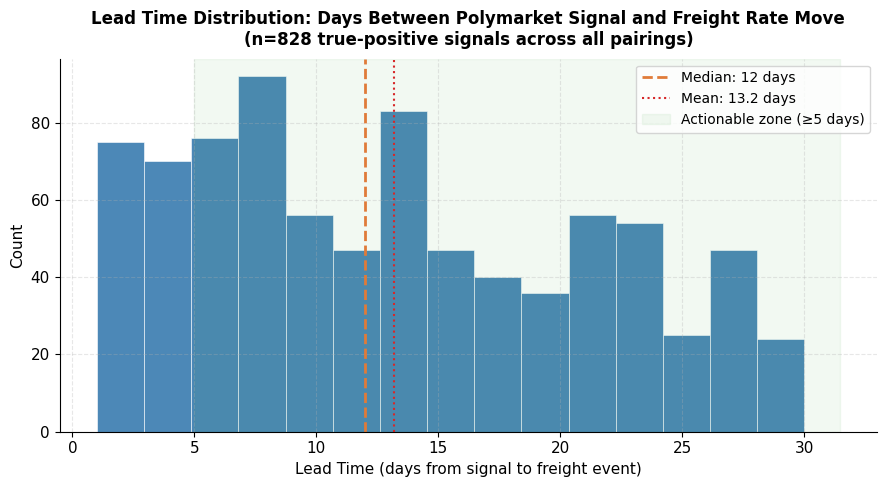

Lead time stats across all TPs (n=828):
  Median : 12 days
  Mean   : 13.2 days
  Min    : 1 days
  Max    : 30 days
  ≥5 days: 683 (82%)


In [56]:
from src.analysis.validation import plot_lead_time_histogram

fig = plot_lead_time_histogram(validations, bins=15, filename_stem='val_lead_time')
plt.show()

all_lead_times = [lt for v in validations for lt in v.lead_times]
if all_lead_times:
    print(f'Lead time stats across all TPs (n={len(all_lead_times)}):')
    print(f'  Median : {np.median(all_lead_times):.0f} days')
    print(f'  Mean   : {np.mean(all_lead_times):.1f} days')
    print(f'  Min    : {min(all_lead_times)} days')
    print(f'  Max    : {max(all_lead_times)} days')
    print(f'  ≥5 days: {sum(1 for lt in all_lead_times if lt >= 5)} ({100 * sum(1 for lt in all_lead_times if lt >= 5) / len(all_lead_times):.0f}%)')
else:
    print('No true-positive signals — no lead times to report.')

## Step 9: Per-event breakdown

Flat table of all individual signal outcomes.  
Filter to TP / FP / FN as needed for deep-dive inspection.

In [57]:
outcomes_df = validator.all_outcomes_dataframe(validations)

if not outcomes_df.empty:
    print(f'Total outcomes: {len(outcomes_df)}  (top 20 shown — full results in validation_report.md)')
    print(outcomes_df['outcome'].value_counts().to_string())
    print()
    display_cols = [
        'market_title', 'freight_index', 'signal_timestamp',
        'signal_delta', 'expected_freight_direction',
        'outcome', 'lead_time_days', 'freight_pct_change',
    ]
    display(outcomes_df[display_cols].head(20))
else:
    print('No outcomes to display.')

Total outcomes: 9720  (top 20 shown — full results in validation_report.md)
outcome
FN    8052
FP     840
TP     828



,market_title,freight_index,signal_timestamp,signal_delta,expected_freight_direction,outcome,lead_time_days,freight_pct_change
0,Iran in possession of nuclear weapons by EoY?,BDI,2023-10-19,0.0150,down,FP,NaN,NaN
1,Will the US publicly state that Iran was direc...,BDI,2023-10-21,-0.1650,up,FP,NaN,NaN
2,Will the US publicly state that Iran was direc...,BDI,2023-11-01,0.1350,down,FP,NaN,NaN
3,Will Iran close the Strait of Hormuz in 2023?,BDI,2023-11-01,0.1050,down,FP,NaN,NaN
4,Iran in possession of nuclear weapons by EoY?,BDI,2023-11-03,-0.0200,up,FP,NaN,NaN
5,Will the US publicly state that Iran was direc...,BDI,2023-11-08,-0.1550,up,FP,NaN,NaN
6,Will Iran close the Strait of Hormuz in 2023?,BDI,2023-11-08,-0.1200,up,FP,NaN,NaN
7,Will US attack Iran by Nov 30?,BDI,2023-11-09,0.0250,up,FP,NaN,NaN
8,Iran in possession of nuclear weapons by EoY?,BDI,2023-11-29,-0.0175,up,FP,NaN,NaN
9,Will the US publicly state that Iran was direc...,BDI,2023-12-14,0.1775,down,FP,NaN,NaN


In [58]:
# True positives only — signals that were followed by a matching freight move
if not outcomes_df.empty:
    tp_df = outcomes_df[outcomes_df['outcome'] == 'TP'].copy()
    print(f'True Positives: {len(tp_df)}  (top 10 shown)')
    if not tp_df.empty:
        display(
            tp_df[[
                'market_title', 'freight_index', 'signal_timestamp',
                'signal_delta', 'expected_freight_direction',
                'lead_time_days', 'freight_pct_change',
            ]]
            .sort_values('lead_time_days')
            .head(10)
        )

True Positives: 828  (top 10 shown)


,market_title,freight_index,signal_timestamp,signal_delta,expected_freight_direction,lead_time_days,freight_pct_change
3730,Will the U.S. agree to a trade deal with India...,FBX01,2025-06-18,-0.445,up,1.0,55.26
1669,Will Trump remove tariff on Canada before May?,FBX03,2025-03-12,-0.275,down,1.0,-9.80
1672,Mexico tariffs on China in effect before July?,FBX01,2025-03-12,0.135,down,1.0,-16.67
3735,Will the U.S. agree to a trade deal with Austr...,FBX_GLOBAL,2025-06-18,-0.125,up,1.0,47.79
3229,US-EU trade agreement by July 9?,FBX11,2025-06-04,-0.155,up,1.0,10.00
5698,Trump imposes tariff on pharmaceuticals by Sep...,FBX03,2025-09-10,0.210,down,1.0,-10.26
5915,Israel strikes Iran by September 30?,BDI,2025-09-16,-0.120,up,1.0,12.37
3736,Will the U.S. agree to a trade deal with Austr...,FBX01,2025-06-18,-0.125,up,1.0,55.26
5695,Will the Court Force Trump to Refund Tariffs?,FBX03,2025-09-10,0.120,down,1.0,-10.26
2544,China x Taiwan military clash by June 30?,FBX03,2025-04-09,0.019,down,1.0,-12.20


In [59]:
# False negatives — significant freight moves with no preceding signal
if not outcomes_df.empty:
    fn_df = outcomes_df[outcomes_df['outcome'] == 'FN'].copy()
    print(f'False Negatives (missed freight moves): {len(fn_df)}  (top 10 shown)')
    if not fn_df.empty:
        display(
            fn_df[[
                'freight_index', 'signal_timestamp',
                'expected_freight_direction', 'freight_pct_change',
            ]]
            .sort_values('freight_pct_change', key=abs, ascending=False)
            .head(10)
        )

False Negatives (missed freight moves): 8052  (top 10 shown)


,freight_index,signal_timestamp,expected_freight_direction,freight_pct_change
1559,BDI,2025-03-03,up,58.31
1560,BDI,2025-03-03,up,58.31
1558,BDI,2025-03-03,up,58.31
1592,BDI,2025-03-03,up,58.31
1630,BDI,2025-03-03,up,58.31
1615,BDI,2025-03-03,up,58.31
1614,BDI,2025-03-03,up,58.31
1612,BDI,2025-03-03,up,58.31
1631,BDI,2025-03-03,up,58.31
1626,BDI,2025-03-03,up,58.31


## Step 10: Aggregate statistics by freight index

Summarise precision and recall pooled across all market pairings per freight index.  
This answers: *"Is Polymarket useful for predicting BDI vs. FBX moves in general?"*

In [60]:
if not summary_df.empty:
    agg = (
        summary_df
        .groupby('freight_index')
        .agg(
            n_pairings=('market_id', 'count'),
            total_signals=('n_signals', 'sum'),
            total_freight_events=('n_freight_events', 'max'),  # events are shared across markets
            total_tp=('n_tp', 'sum'),
            total_fp=('n_fp', 'sum'),
            total_fn=('n_fn', 'sum'),
            mean_precision=('precision', 'mean'),
            mean_recall=('recall', 'mean'),
            mean_f1=('f1', 'mean'),
            median_lead_time=('median_lead_time_days', 'median'),
        )
        .reset_index()
    )
    agg['pooled_precision'] = agg['total_tp'] / (agg['total_tp'] + agg['total_fp']).clip(lower=1)
    agg['pooled_recall']    = agg['total_tp'] / (agg['total_tp'] + agg['total_fn']).clip(lower=1)
    display(
        agg[[
            'freight_index', 'n_pairings', 'total_signals',
            'total_tp', 'total_fp', 'total_fn',
            'pooled_precision', 'pooled_recall',
            'mean_f1', 'median_lead_time',
        ]]
        .sort_values('pooled_precision', ascending=False)
        .style
        .background_gradient(
            subset=['pooled_precision', 'pooled_recall', 'mean_f1'],
            cmap='RdYlGn', vmin=0, vmax=1
        )
        .format({
            'pooled_precision': '{:.2f}',
            'pooled_recall': '{:.2f}',
            'mean_f1': '{:.2f}',
            'median_lead_time': lambda x: f'{x:.0f}d' if pd.notna(x) else '—',
        })
    )
else:
    print('No summary data available.')

,freight_index,n_pairings,total_signals,total_tp,total_fp,total_fn,pooled_precision,pooled_recall,mean_f1,median_lead_time
2,FBX03,152,519,292,227,2427,0.56,0.11,0.17,12d
4,FBX_GLOBAL,55,201,100,101,781,0.50,0.11,0.17,12d
1,FBX01,195,690,328,362,2783,0.48,0.11,0.16,13d
3,FBX11,15,46,20,26,189,0.43,0.10,0.15,8d
0,BDI,72,212,88,124,1872,0.42,0.04,0.08,12d


## Interpretation & Caveats

### How to read the results

**Precision** tells you how much to trust a signal when it fires.  
A precision of 0.7 means 7 out of 10 signals were followed by a freight move in the expected direction.

**Recall** tells you how comprehensive the signal coverage is.  
A recall of 0.5 means only half of the significant freight moves were preceded by a Polymarket signal — the other half were blind spots.

**Lead time** is the operational variable.  
A median lead time of <5 days is marginal for most supply chain decisions.  
10–20 days is actionable for routing, booking, and inventory decisions.

### Key limitations

1. **Spurious correlations**: Some pairings (e.g., sports outcomes correlated with freight indexes) pass statistical tests by chance.  
   Always verify that the causal logic makes sense before trusting a pairing.

2. **Freight data coverage**: FBX indexes currently cover ~27 weekly observations, limiting statistical power.  
   Extend coverage with historical FBX data for more reliable validation.

3. **Outcome window sensitivity**: Changing the outcome window from 30 to 14 days can significantly shift precision/recall.  
   Re-run the `SignalValidator` with different parameters to assess robustness.

4. **Prediction markets can only signal *anticipated* risks**.  
   Sudden unforeseeable events (port accidents, natural disasters) will always appear as FNs — this is a structural limitation, not a data quality issue.

5. **Category assignment**: Market discovery used keyword matching.  
   Some markets may be miscategorised; review the SC market list before drawing conclusions.

## Step 11: Export validation report

Writes the full validation results to `output/validation_report.md` — all pairings and all outcomes, not truncated.

In [61]:
from datetime import datetime

OUTPUT_DIR = BASE / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_PATH = OUTPUT_DIR / 'validation_report.md'

generated_at = datetime.now().strftime('%Y-%m-%d %H:%M UTC')

def _md_table(df: pd.DataFrame, float_fmt: dict = None) -> str:
    """Render a DataFrame as a GitHub-flavoured markdown table.

    float_fmt: {col_name: format_string} applied before NaN→'—' substitution.
    NaN values in any column render as '—'.
    """
    float_fmt = float_fmt or {}
    df = df.copy()
    # Apply numeric formatting first, while columns are still numeric
    for col, fmt in float_fmt.items():
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: fmt.format(float(x)) if pd.notna(x) else '—'
            )
    header = '| ' + ' | '.join(str(c) for c in df.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(df.columns)) + ' |'
    rows   = [
        '| ' + ' | '.join(
            '—' if (v is None or (isinstance(v, float) and np.isnan(v))) else str(v)
            for v in row
        ) + ' |'
        for row in df.itertuples(index=False)
    ]
    return '\n'.join([header, sep] + rows)


# ── Section helpers ────────────────────────────────────────────────────────────

def _overview_section() -> str:
    total_tp = summary_df['n_tp'].sum() if not summary_df.empty else 0
    total_fp = summary_df['n_fp'].sum() if not summary_df.empty else 0
    total_fn = summary_df['n_fn'].sum() if not summary_df.empty else 0
    total_signals = summary_df['n_signals'].sum() if not summary_df.empty else 0
    pooled_prec = total_tp / max(total_tp + total_fp, 1)
    pooled_rec  = total_tp / max(total_tp + total_fn, 1)
    all_lts     = [lt for v in validations for lt in v.lead_times]
    lt_median   = f'{np.median(all_lts):.0f} days' if all_lts else '—'
    lt_actionable = (
        f'{100 * sum(1 for lt in all_lts if lt >= 5) / max(len(all_lts), 1):.0f}%'
        if all_lts else '—'
    )
    return (
        '## Overview\n\n'
        f'- **Pairings evaluated:** {len(validations)}\n'
        f'- **Total Polymarket signals:** {total_signals:,}\n'
        f'- **True Positives (TP):** {total_tp}\n'
        f'- **False Positives (FP):** {total_fp}\n'
        f'- **False Negatives (FN):** {total_fn}\n'
        f'- **Pooled Precision:** {pooled_prec:.2f}\n'
        f'- **Pooled Recall:** {pooled_rec:.2f}\n'
        f'- **Median Lead Time:** {lt_median}\n'
        f'- **Signals with ≥5 day lead:** {lt_actionable}\n'
        f'- **Freight event threshold:** ≥{FREIGHT_THRESHOLD_PCT*100:.0f}% change over {FREIGHT_EVENT_WINDOW} days\n'
        f'- **Outcome window:** {validator.outcome_window} days\n'
        f'- **Lookback window:** {validator.lookback_window} days\n'
    )


def _pairing_summary_section() -> str:
    if summary_df.empty:
        return '## Pairing Summary\n\n*No results.*\n'
    cols = ['market_title', 'freight_index', 'peak_correlation', 'peak_lag_days',
            'poly_leads', 'n_tp', 'n_fp', 'n_fn', 'precision', 'recall', 'f1',
            'median_lead_time_days']
    table = _md_table(
        summary_df[cols],
        float_fmt={
            'peak_correlation': '{:.3f}',
            'precision': '{:.2f}', 'recall': '{:.2f}', 'f1': '{:.2f}',
            'median_lead_time_days': '{:.0f}',
        }
    )
    return f'## Pairing Summary (all {len(summary_df)} pairings, sorted by F1)\n\n{table}\n'


def _freight_index_section() -> str:
    if summary_df.empty or 'freight_index' not in summary_df.columns:
        return ''
    agg = (
        summary_df.groupby('freight_index')
        .agg(
            n_pairings=('market_id', 'count'),
            total_tp=('n_tp', 'sum'), total_fp=('n_fp', 'sum'), total_fn=('n_fn', 'sum'),
            mean_f1=('f1', 'mean'), median_lead=('median_lead_time_days', 'median'),
        )
        .reset_index()
    )
    agg['pooled_precision'] = agg['total_tp'] / (agg['total_tp'] + agg['total_fp']).clip(lower=1)
    agg['pooled_recall']    = agg['total_tp'] / (agg['total_tp'] + agg['total_fn']).clip(lower=1)
    agg = agg.sort_values('pooled_precision', ascending=False)
    table = _md_table(
        agg[['freight_index', 'n_pairings', 'total_tp', 'total_fp', 'total_fn',
             'pooled_precision', 'pooled_recall', 'mean_f1', 'median_lead']],
        float_fmt={
            'pooled_precision': '{:.2f}', 'pooled_recall': '{:.2f}',
            'mean_f1': '{:.2f}', 'median_lead': '{:.0f}',
        }
    )
    return f'## Results by Freight Index\n\n{table}\n'


def _true_positives_section() -> str:
    if outcomes_df.empty:
        return ''
    tp = outcomes_df[outcomes_df['outcome'] == 'TP'].copy()
    if tp.empty:
        return '## True Positives\n\n*None detected.*\n'
    cols = ['market_title', 'freight_index', 'signal_timestamp',
            'signal_delta', 'expected_freight_direction', 'lead_time_days', 'freight_pct_change']
    table = _md_table(
        tp[cols].sort_values('lead_time_days'),
        float_fmt={'signal_delta': '{:.3f}', 'freight_pct_change': '{:.1f}'}
    )
    return f'## True Positives ({len(tp)} signals correctly predicted)\n\n{table}\n'


def _false_negatives_section() -> str:
    if outcomes_df.empty:
        return ''
    fn = outcomes_df[outcomes_df['outcome'] == 'FN'].copy()
    if fn.empty:
        return '## False Negatives\n\n*None — all freight moves had a preceding signal.*\n'
    cols = ['freight_index', 'signal_timestamp', 'expected_freight_direction', 'freight_pct_change']
    table = _md_table(
        fn[cols].sort_values('freight_pct_change', key=abs, ascending=False),
        float_fmt={'freight_pct_change': '{:.1f}'}
    )
    return (
        f'## False Negatives ({len(fn)} freight moves with no preceding signal)\n\n'
        '*These are supply chain disruptions that Polymarket did not anticipate — '
        'structural blind spots (sudden accidents, weather) are expected here.*\n\n'
        f'{table}\n'
    )


def _caveats_section() -> str:
    return (
        '## Caveats\n\n'
        '1. **Spurious correlations**: Pairings were pre-filtered by SC title keywords; '
        'residual noise is possible.\n'
        '2. **Freight data coverage**: FBX indexes cover ~27 weekly observations — '
        'extend coverage for more robust validation.\n'
        '3. **Outcome window sensitivity**: Results assume a 30-day outcome window; '
        'different windows will change precision/recall.\n'
        '4. **Structural blind spots**: Sudden unforeseeable events cannot appear as '
        'Polymarket signals and will always be FNs.\n'
        '5. **Direction mapping**: Expected freight direction is inferred from the '
        'cross-correlation sign; weak correlations (|r| < 0.10) are excluded.\n'
    )


# ── Assemble and write ─────────────────────────────────────────────────────────
sections = [
    '# Polymarket SCM Intel — Signal Validation Report',
    f'*Generated: {generated_at}*',
    '---',
    _overview_section(),
    '---',
    _pairing_summary_section(),
    '---',
    _freight_index_section(),
    '---',
    _true_positives_section(),
    '---',
    _false_negatives_section(),
    '---',
    _caveats_section(),
    '---',
    '*Polymarket SCM Intelligence MVP — Validation Report*',
]

report_text = '\n\n'.join(s for s in sections if s)
REPORT_PATH.write_text(report_text, encoding='utf-8')
print(f'Validation report saved → {REPORT_PATH.resolve()}')
print(f'  {len(summary_df)} pairings | {len(outcomes_df)} outcomes')

Validation report saved → C:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\output\validation_report.md
  489 pairings | 9720 outcomes
